# Phase 3 — AION tokenizer evaluation (local)

Understand **code diversity** and batch behavior of the frozen AION DESI codec before / during transformer training.

**Not included:** legacy in-repo codec versions (v2–v5). Those paths are deprecated for Phase 5.

**Requirements:** `.venv` with `polymathic-aion`, `HF_TOKEN` in `.env`, and (for real spectra) Phase 1 manifest under `data/manifests/train_eval_dr1.jsonl`.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

_cwd = Path.cwd().resolve()
if (_cwd / "src" / "desifm").is_dir():
    REPO = _cwd
elif (_cwd.parent / "src" / "desifm").is_dir():
    REPO = _cwd.parent
else:
    raise FileNotFoundError(f"Could not find repo root (src/desifm). cwd={_cwd}")
sys.path.insert(0, str(REPO / "src"))

try:
    from IPython import get_ipython

    _ip = get_ipython()
    if _ip is not None:
        _ip.run_line_magic("matplotlib", "inline")
except Exception:
    pass

plt.rcParams["figure.figsize"] = (12, 4)

from desifm.constants import GRID_SIZE, N_LATENT_TOKENS, N_SPECTRUM_CODES, SPECTRUM_OFFSET
from desifm.training.env import load_project_env

load_project_env()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("REPO:", REPO)
print("device:", DEVICE)
print(f"GRID_SIZE={GRID_SIZE}  N_LATENT_TOKENS={N_LATENT_TOKENS}  N_SPECTRUM_CODES={N_SPECTRUM_CODES}")


REPO: /Users/jonathansamuel/projects/cs-686-dl/final-project
device: cpu
GRID_SIZE=8704  N_LATENT_TOKENS=273  N_SPECTRUM_CODES=1024


## 1. Download one DR1 tile (if needed)

Same minimal setup as Phase 1.


In [2]:
from desifm.data.public_dr1 import discover_public_training_tiles, ensure_dr1_tiles_local
from desifm.data.dr1_stream import load_manifest

DATA_ROOT = REPO / "data" / "dr1_public"
MANIFEST = REPO / "data" / "manifests" / "train_eval_dr1.jsonl"
N_HEALPIX = 1

if MANIFEST.is_file():
    print("manifest exists:", MANIFEST)
else:
    tiles = discover_public_training_tiles(N_HEALPIX)
    print("tiles:", tiles)
    ensure_dr1_tiles_local(DATA_ROOT, MANIFEST, tiles)
    for r in load_manifest(MANIFEST):
        print(f"  healpix {r['healpix']} n_rows={r.get('n_rows')}")


manifest exists: /Users/jonathansamuel/projects/cs-686-dl/final-project/data/manifests/train_eval_dr1.jsonl


## 2. Build evaluation batch

In [3]:
from desifm.data.dr1_stream import DR1StreamDataset, collate_spectra
from desifm.tokenization.aion_bridge import AionSpectrumTokenizer

try:
    import aion  # noqa: F401
except ImportError as e:
    raise ImportError('pip install -e ".[aion]"') from e

N_SPECTRA = 16
records = load_manifest(MANIFEST)
ds = DR1StreamDataset(records, max_spectra=N_SPECTRA * 3)
items = []
for i in range(len(ds)):
    it = ds[i]
    if it is not None:
        items.append(it)
    if len(items) >= N_SPECTRA:
        break
assert items, "no valid spectra — check manifest / FITS paths"
batch = collate_spectra(items)
print("batch flux:", tuple(batch["flux"].shape))

tok = AionSpectrumTokenizer(DEVICE)
spec_idx, meta = tok.encode_batch(batch)
print("codes:", tuple(spec_idx.shape), meta)


/Users/jonathansamuel/projects/cs-686-dl/final-project/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


batch flux: (16, 7781)
codes: (16, 273) {'resampled_to_grid': True, 'grid_size': 8704}


## 3. Diversity metrics

Healthy AION usage: hundreds of unique codes per batch (not collapse to a handful). Compare to W&B `train/spec_codes_unique` during transformer training.


batch n_unique: 979 / 1024
per-spectrum unique: min=221 median=237 max=245


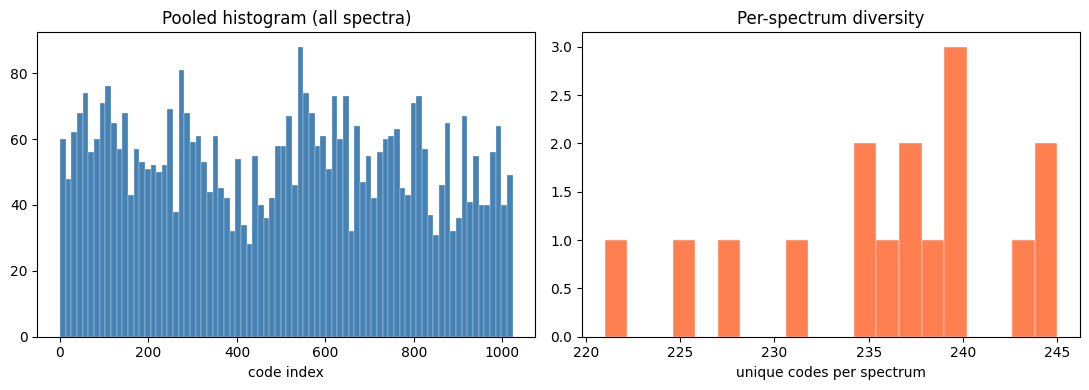

In [4]:
codes = spec_idx.cpu().numpy()
n_unique_batch = len(np.unique(codes))
per_spec_unique = [len(np.unique(codes[i])) for i in range(codes.shape[0])]

print(f"batch n_unique: {n_unique_batch} / {N_SPECTRUM_CODES}")
print(f"per-spectrum unique: min={min(per_spec_unique)} median={int(np.median(per_spec_unique))} max={max(per_spec_unique)}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(codes.ravel(), bins=80, color="steelblue", edgecolor="white", linewidth=0.2)
axes[0].set_xlabel("code index")
axes[0].set_title("Pooled histogram (all spectra)")
axes[1].hist(per_spec_unique, bins=20, color="coral", edgecolor="white", linewidth=0.3)
axes[1].set_xlabel("unique codes per spectrum")
axes[1].set_title("Per-spectrum diversity")
plt.tight_layout()
plt.show()


## 4. Heatmap: codes × spectrum

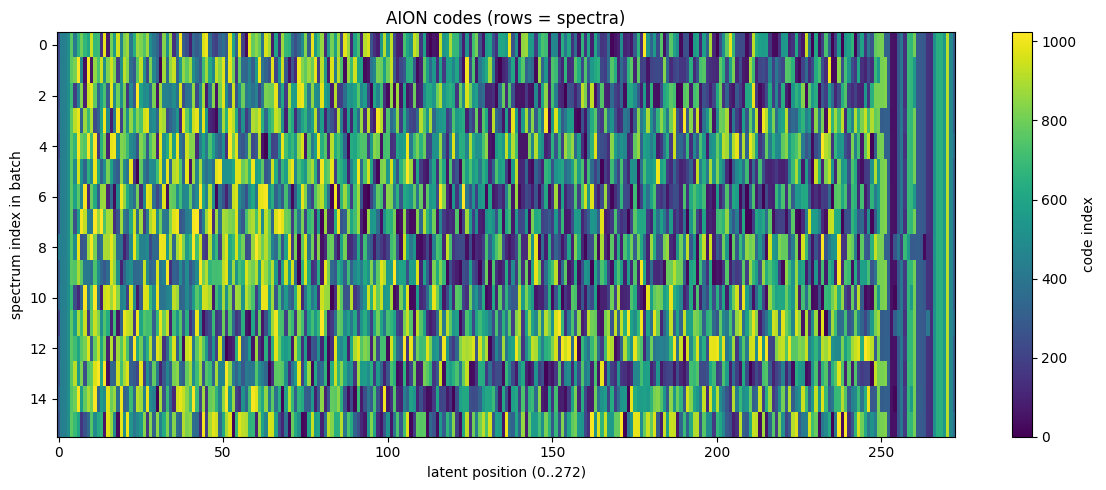

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(codes, aspect="auto", interpolation="nearest", cmap="viridis", vmin=0, vmax=N_SPECTRUM_CODES - 1)
ax.set_xlabel("latent position (0..272)")
ax.set_ylabel("spectrum index in batch")
ax.set_title("AION codes (rows = spectra)")
plt.colorbar(im, ax=ax, label="code index")
plt.tight_layout()
plt.show()


## 5. Overlay: flux + code positions (one spectrum)

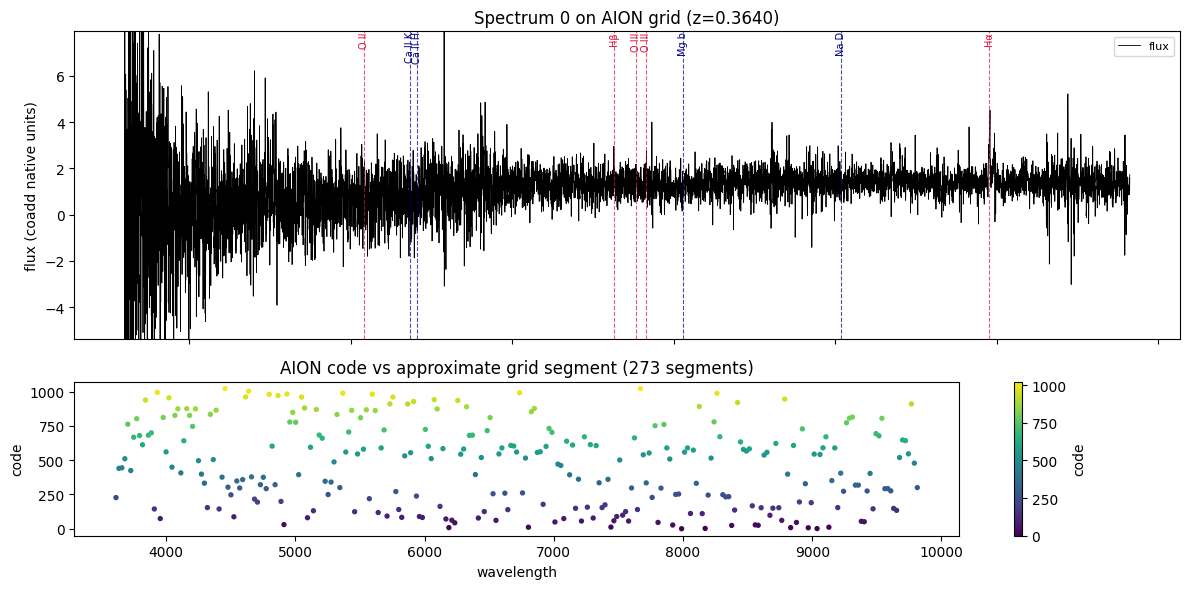

In [6]:
from desifm.tokenization.aion_grid import resample_spectrum_batch
from desifm.viz.spectrum_plot import plot_spectrum_with_lines

idx = 0
flux_g, _, mask_g, wave_g, _ = resample_spectrum_batch(
    batch["flux"][idx : idx + 1],
    batch["ivar"][idx : idx + 1],
    batch["mask"][idx : idx + 1],
    batch["wavelength"][idx : idx + 1],
    length=GRID_SIZE,
)
wave_np = wave_g[0].cpu().numpy()
flux_np = flux_g[0].cpu().numpy()
seq = codes[idx]

# Map each of 273 tokens to a bin along the grid (uniform split)
edges = np.linspace(0, GRID_SIZE, N_LATENT_TOKENS + 1, dtype=int)
centers = [(edges[i] + edges[i + 1]) // 2 for i in range(N_LATENT_TOKENS)]

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
z_plot = float(items[idx]["z"].item())
plot_spectrum_with_lines(axes[0], wave_np, flux_np, z=z_plot, title=f"Spectrum {idx} on AION grid (z={z_plot:.4f})")
axes[0].set_xlabel("")

sc = axes[1].scatter(wave_np[centers], seq, c=seq, cmap="viridis", s=8, vmin=0, vmax=N_SPECTRUM_CODES - 1)
axes[1].set_ylabel("code")
axes[1].set_xlabel("wavelength")
axes[1].set_title("AION code vs approximate grid segment (273 segments)")
plt.colorbar(sc, ax=axes[1], label="code")
plt.tight_layout()
plt.show()


## 6. Synthetic vs real (optional)

Quick check that synthetic smoke spectra also get diverse codes.


In [7]:
from desifm.data.synthetic import SyntheticSpectrumDataset

syn_items = [SyntheticSpectrumDataset(n_spectra=1, length=5000, seed=i)[0] for i in range(8)]
syn_batch = collate_spectra(syn_items)
syn_idx, _ = tok.encode_batch(syn_batch)
syn_u = int(syn_idx.unique().numel())
print(f"synthetic batch n_unique: {syn_u}")
print(f"real DR1 batch n_unique:   {n_unique_batch}")


synthetic batch n_unique: 648
real DR1 batch n_unique:   979


## 7. Smoke script

```bash
.venv/bin/python scripts/smoke_aion_tokenizer.py --synthetic
.venv/bin/python scripts/smoke_aion_tokenizer.py --manifest data/manifests/train_eval_dr1.jsonl --batch-size 4 --device cuda
```

Logs: `checkpoints/<run-name>/smoke.log` and `metrics.jsonl`.
